In [208]:
##1. cars.csv와 brand.csv의 데이터 합치기 // [힌트] cars.csv의 title 변수로부터 브랜드 데이터를 추출할 수 있습니다.
##2. 카테고리형 변수를 숫자 형태로 변환하기 // [힌트] Engine, Emission Class 변수에 주목하세요!
##3. 결측치 처리하기 // [힌트] Service history 변수의 결측치는 'Unknown'으로 채우고, 결측치 변수가 ##4. 일정 개수 이상 포함된 데이터는 제거합니다.
##5. Scaler 활용해보기
##6. 기존 데이터의 정보 70% 이상을 가지는 수준에서 최소한의 주성분 추출 (PCA)
##7. 국가별 총 브랜드 개수는?
##8. 상관관계가 높은 변수들이 있는지 확인해보세요.

In [209]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

brand = pd.read_csv('./brand.csv')
cars = pd.read_csv('./cars.csv')

In [210]:
brand.head()

,title,country
0,skoda,Czech Republic
1,vauxhall,United Kingdom
2,hyundai,South Korea
3,mini,United Kingdom
4,ford,United States


In [211]:
brand.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    48 non-null     object
 1   country  48 non-null     object
dtypes: object(2)
memory usage: 896.0+ bytes


In [212]:
cars.head()

,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full
2,HYUNDAI I30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full
4,VAUXHALL CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN


In [213]:
cars.info() #데이터타입 이상없음. 결측치가 존재함.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3687 entries, 0 to 3686
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              3687 non-null   object 
 1   Price              3687 non-null   int64  
 2   Mileage(miles)     3687 non-null   int64  
 3   Registration_Year  3687 non-null   int64  
 4   Previous Owners    2276 non-null   float64
 5   Fuel type          3687 non-null   object 
 6   Body type          3687 non-null   object 
 7   Engine             3642 non-null   object 
 8   Gearbox            3687 non-null   object 
 9   Doors              3662 non-null   float64
 10  Seats              3652 non-null   float64
 11  Emission Class     3600 non-null   object 
 12  Service history    540 non-null    object 
dtypes: float64(3), int64(3), object(7)
memory usage: 374.6+ KB


In [214]:
#0. 데이터 병합을 우선적으로 진행.
#1. 가격이 압도적으로 비싼 모델이 있음. 확인해봐야함.
#2. 1,110,100*1.60934 = 1,786,304km 말도 안되는 수치는 아님. 확인은 해보기.
#3. 이전소유자가 굉장히 많은 차량이 존재함 확인 해보기.
#4. Door가 5개인 차량이 있나? SUV,RV차량이 헤치백을 포함하여 5도어로 구분된다고 함.

cars.describe()

,Price,Mileage(miles),Registration_Year,Previous Owners,Doors,Seats
count,3687.000000,3.687000e+03,3687.000000,2276.000000,3662.000000,3652.000000
mean,5787.301058,8.132854e+04,2011.846216,2.807557,4.321409,4.900329
std,4480.629885,3.941718e+04,5.082387,1.546028,0.986760,0.577046
min,400.000000,1.000000e+00,1953.000000,1.000000,2.000000,2.000000
25%,2490.000000,5.698400e+04,2008.000000,2.000000,3.000000,5.000000
50%,4000.000000,8.000000e+04,2012.000000,3.000000,5.000000,5.000000
75%,7995.000000,1.030000e+05,2015.500000,4.000000,5.000000,5.000000
max,33900.000000,1.110100e+06,2025.000000,9.000000,5.000000,7.000000


In [215]:
#양 브랜드명을 소문자로 변경하고 브랜드명을 통일시킬필요가 있어보임.
print(cars["title"].unique())
print(brand["title"].unique())

['SKODA FABIA' 'VAUXHALL CORSA' 'HYUNDAI I30' 'MINI HATCH' 'HYUNDAI COUPE'
 'FORD FOCUS' 'VOLVO 740' 'PEUGEOT 207' 'FORD FIESTA' 'VAUXHALL INSIGNIA'
 'BMW 3 SERIES' 'CITROEN C1' 'CITROEN C4' 'VAUXHALL ASTRA' 'FORD MONDEO'
 'MERCEDES-BENZ A180' 'PEUGEOT 407' 'FORD KA' 'MERCEDES-BENZ A CLASS'
 'MAZDA MAZDA2' 'SAAB 9-3' 'VOLKSWAGEN POLO' 'BMW 1 SERIES' 'HONDA ACCORD'
 'VOLKSWAGEN BEETLE' 'MG MG6' 'FORD C-MAX' 'HONDA CIVIC' 'TOYOTA AURIS'
 'VOLVO S40' 'SEAT IBIZA' 'PEUGEOT 308' 'VAUXHALL MERIVA'
 'MERCEDES-BENZ B CLASS' 'MAZDA MAZDA3' 'NISSAN 350 Z' 'ALFA ROMEO MITO'
 'RENAULT FLUENCE' 'VOLKSWAGEN PASSAT' 'KIA SPORTAGE' 'CITROEN XM'
 'VAUXHALL ANTARA' 'NISSAN NOTE' 'BMW 5 SERIES' 'HONDA CR-V'
 'PROTON SAVVY' 'NISSAN MICRA' 'FIAT PANDA' 'RENAULT MEGANE'
 'RENAULT CLIO' 'HYUNDAI I20' 'CITROEN C3' 'AUDI A6 SALOON' 'TOYOTA YARIS'
 'FIAT 500' 'MERCEDES-BENZ M CLASS' 'AUDI A4' 'PEUGEOT 308 SW'
 'FORD S-MAX' 'PEUGEOT 1007' 'HONDA ODYSSEY' 'PEUGEOT 307 CC' 'HONDA JAZZ'
 'MERCEDES-BENZ CLK' 'CITROE

In [216]:
#cars의 title에서 스플릿하여 0번째 인덱스만 소문자로 변환
#brand의 title도 소문자로 변환.
#기존 차량명은 두고 따로 brand 컬럼 생성하여 병합

cars["brand"] = cars["title"].str.split().str[0].str.lower()

brand["title"] = brand["title"].str.lower()

brand = brand.rename(columns={"title": "brand"})

cars = pd.merge(cars, brand[["brand", "country"]], on="brand", how="left")

print(cars.columns)

display(cars.head()) #병합 후, 확인

Index(['title', 'Price', 'Mileage(miles)', 'Registration_Year',
       'Previous Owners', 'Fuel type', 'Body type', 'Engine', 'Gearbox',
       'Doors', 'Seats', 'Emission Class', 'Service history', 'brand',
       'country'],
      dtype='object')


,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,brand,country
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN,skoda,Czech Republic
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full,vauxhall,United Kingdom
2,HYUNDAI I30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN,hyundai,South Korea
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full,mini,United Kingdom
4,VAUXHALL CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN,vauxhall,United Kingdom


3245      400
3278      450
1238      495
3246      499
3429      500
        ...  
3102    25995
3230    25995
3224    28240
2936    30000
3212    33900
Name: Price, Length: 3687, dtype: int64
title                MERCEDES-BENZ GLE CLASS
Price                                  33900
Mileage(miles)                         92000
Registration_Year                       2019
Previous Owners                          1.0
Fuel type                             Diesel
Body type                                SUV
Engine                                  2.0L
Gearbox                            Automatic
Doors                                    5.0
Seats                                    5.0
Emission Class                        Euro 6
Service history                          NaN
brand                          mercedes-benz
country                              Germany
Name: 3212, dtype: object


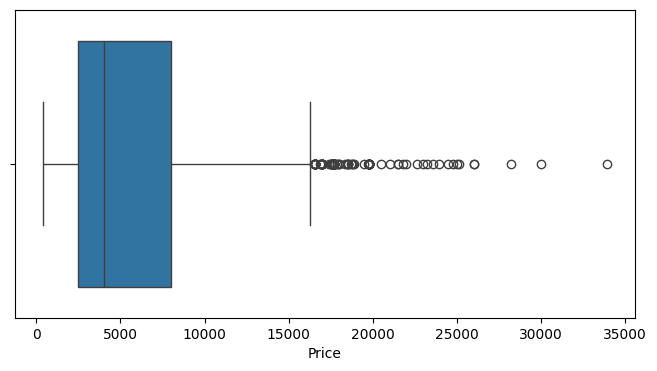

In [217]:
#Price중 가장 높은 값과 낮은 값의 데이터를 확인하여 이상치인지 확인

print(cars['Price'].sort_values())

print(cars.iloc[3212])

plt.figure(figsize=(8,4))
sns.boxplot(x=cars["Price"])
plt.show()

#Price가 높은 값이 이상치같아보이진 않음.

3219          1
3100          1
2013          6
3102        222
2760       1048
         ...   
1933     274100
2048     274100
1478     274100
1259     274100
1037    1110100
Name: Mileage(miles), Length: 3687, dtype: int64
title                VOLKSWAGEN BEETLE
Price                             2495
Mileage(miles)                 1110100
Registration_Year                 2003
Previous Owners                    4.0
Fuel type                       Petrol
Body type                    Hatchback
Engine                            2.0L
Gearbox                      Automatic
Doors                              3.0
Seats                              4.0
Emission Class                  Euro 4
Service history                    NaN
brand                       volkswagen
country                        Germany
Name: 1037, dtype: object


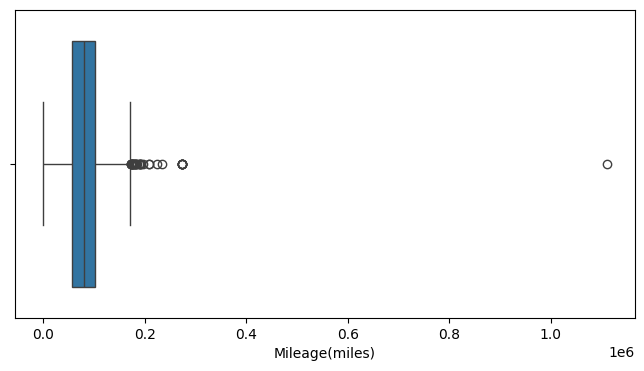

count    3.687000e+03
mean     8.132854e+04
std      3.941718e+04
min      1.000000e+00
25%      5.698400e+04
50%      8.000000e+04
75%      1.030000e+05
max      1.110100e+06
Name: Mileage(miles), dtype: float64


In [218]:
#마일수가 지나치게 높은값이 하나 존재하여, 정렬한 뒤 해당값을 확인했음.

print(cars['Mileage(miles)'].sort_values())

print(cars.iloc[1037])

plt.figure(figsize=(8,4))
sns.boxplot(x=cars["Mileage(miles)"])
plt.show()
print(cars["Mileage(miles)"].describe())

#마일수가 지나치게 높은 값이 하나 존재하여, 모델링에 문제가 있을 수 있어 드랍하는게 맞다고 생각 됨.(드랍이유에 대한 기준이 Price와 비교했을때 부족함.+ 보완.)

In [219]:
#Previous Owners의 값에 대한 분포 확인

print(cars["Previous Owners"].unique())
print(cars["Previous Owners"].value_counts())

#차주가 바뀔 수 있으므로 큰 이상치는 아닌것으로 파악됨.

[ 3.  4. nan  5.  1.  2.  6.  7.  9.  8.]
Previous Owners
2.0    594
1.0    523
3.0    475
4.0    360
5.0    208
6.0     60
7.0     39
8.0     12
9.0      5
Name: count, dtype: int64


In [220]:
#해치백이 있거나 SUV, SR차량은 문이 5개라고 함. 그렇다면 바디타입이 해치백이라면 문이 5개여야함.

print(cars["Body type"].unique())

['Hatchback' 'Coupe' 'Estate' 'Saloon' 'Convertible' 'MPV' 'SUV' 'Minibus'
 'Combi Van' 'Pickup']


In [221]:
hb = cars[cars["Body type"] == "Hatchback"].copy()

print("\n[Hatchback의 Doors 분포]")
print(hb["Doors"].value_counts())

# Hatchback이며 Doors가 3 또는 5가 아닌 데이터 찾기
hb_invalid = hb[~hb["Doors"].isin([3, 5])]

print("\n[체크] Hatchback인데 Doors가 3/5가 아닌 차량들:")
display(hb_invalid)

print(f"\n총 Hatchback 차량 수: {len(hb)}")
print(f"3도어/5도어 외의 Hatchback 차량 수: {len(hb_invalid)}")


[Hatchback의 Doors 분포]
Doors
5.0    1563
3.0     703
4.0       1
Name: count, dtype: int64

[체크] Hatchback인데 Doors가 3/5가 아닌 차량들:


,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,brand,country
333,HYUNDAI VELOSTER,3999,117000,2012,3.0,Petrol,Hatchback,1.6L,Manual,4.0,4.0,Euro 5,NaN,hyundai,South Korea
595,VAUXHALL ASTRA,3950,56800,2015,4.0,Diesel,Hatchback,1.7L,Manual,NaN,5.0,NaN,NaN,vauxhall,United Kingdom
823,VOLKSWAGEN POLO,6700,49600,2012,NaN,Petrol,Hatchback,1.2L,Automatic,NaN,NaN,NaN,NaN,volkswagen,Germany
856,NISSAN CUBIC,4500,47000,2007,3.0,Petrol,Hatchback,NaN,Manual,NaN,NaN,NaN,NaN,nissan,Japan
1038,HONDA JAZZ,6750,33000,2013,NaN,Petrol Hybrid,Hatchback,1.5L,Automatic,NaN,5.0,NaN,NaN,honda,Japan
1058,VOLKSWAGEN POLO,6450,53193,2011,NaN,Petrol,Hatchback,1.2L,Automatic,NaN,5.0,NaN,NaN,volkswagen,Germany
1140,VOLKSWAGEN POLO,6900,35515,2012,NaN,Petrol,Hatchback,1.2L,Automatic,NaN,5.0,NaN,NaN,volkswagen,Germany
1533,CITROEN C1,3900,71000,2015,3.0,Petrol,Hatchback,NaN,Manual,NaN,NaN,NaN,NaN,citroen,France
1613,VOLKSWAGEN GOLF,1895,61000,2001,5.0,Petrol,Hatchback,1.6L,Automatic,NaN,5.0,NaN,NaN,volkswagen,Germany
1619,FORD KA,2490,68837,2007,4.0,Petrol,Hatchback,NaN,Manual,NaN,NaN,NaN,Full,ford,United States



총 Hatchback 차량 수: 2280
3도어/5도어 외의 Hatchback 차량 수: 14
